# Signal Chain Walkthrough — Vision → Curl Fraction → Servo / Gazebo Command

This notebook traces **one finger** (the index finger) through every transformation in the
real pipeline, using synthetic-but-realistic landmark data instead of a live webcam, so it
runs anywhere without `mediapipe` or the `robohand` conda env.

Every formula below is copied **verbatim** from the real source files, with the exact file
and line referenced, so the numbers here are traceable back to production code — this is
not a simplified approximation of the pipeline, it's the same math run on synthetic input.

**Source files this mirrors:**
- `vision/hand_tracker.py` — landmark → angle → EMA smoothing → curl fraction → servo command
- `sim/bridge/gz_hand_bridge.py` — curl fraction → radian joint target

**Important correction vs. earlier verbal walkthroughs of this pipeline:** the EMA smoothing
happens on the **raw angle in degrees** (`smoothed_angles`, `hand_tracker.py:195-202`), and
`curl_fraction` + inversion is applied *after* smoothing, at `hand_tracker.py:209-212` — not
the other way around. So the real order is:

```
landmarks -> angle (deg, noisy) -> EMA-smoothed angle (deg) -> curl_fraction + invert (%) -> servo cmd / radians
```

Both the servo path and the Gazebo path are derived from the *same* post-smoothing values
(`smoothed_angles` and `curls_by_hand` respectively) — they don't diverge before that point.


In [3]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)  # reproducible synthetic noise
plt.rcParams["figure.facecolor"] = "white"


## Layer 0/1 — Stand-in for camera + MediaPipe: synthetic landmarks

The real pipeline gets 21 `(x, y, z)` points per hand from MediaPipe (`vision/hand_tracker.py:62`,
`find_hands()`). We only need 2 of those 21 points for the angle formula used here — the
wrist (landmark 0) and the index MCP knuckle (landmark 5) and fingertip (landmark 8), per
`FINGER_JOINTS["index"] = (5, 6, 8)` at `hand_tracker.py:40`.

We simulate **5 frames** of the index finger closing from fully open to fully curled. The
wrist and knuckle are (roughly) stationary — a real hand's knuckle doesn't move much relative
to the wrist during a finger curl — while the fingertip sweeps from an "open" position to a
"curled back toward the palm" position. Gaussian noise is added to the fingertip position
per frame, mimicking the sub-pixel landmark jitter MediaPipe actually produces even for a
still hand (this is exactly the noise Layer 4's EMA smoothing exists to damp).

In [4]:
WRIST = np.array([300.0, 400.0])
MCP   = np.array([310.0, 220.0])       # index knuckle, roughly stationary
TIP_OPEN   = np.array([300.0, 140.0])  # finger fully extended
TIP_CLOSED = np.array([280.0, 250.0])  # finger curled back toward the palm

N_FRAMES = 5
t = np.linspace(0.0, 1.0, N_FRAMES)           # 0 = open, 1 = fully curled
NOISE_SIGMA_PX = 6.0                           # simulated landmark jitter, in pixels

tips = np.array([
    (1 - ti) * TIP_OPEN + ti * TIP_CLOSED + np.random.normal(0, NOISE_SIGMA_PX, size=2)
    for ti in t
])

print("Synthetic fingertip positions per frame (pixels):")
for i, tip in enumerate(tips):
    print(f"  frame {i}: tip = ({tip[0]:.1f}, {tip[1]:.1f})")


Synthetic fingertip positions per frame (pixels):
  frame 0: tip = (310.1, 137.2)
  frame 1: tip = (295.2, 169.9)
  frame 2: tip = (285.3, 195.0)
  frame 3: tip = (285.0, 212.0)
  frame 4: tip = (286.1, 253.6)


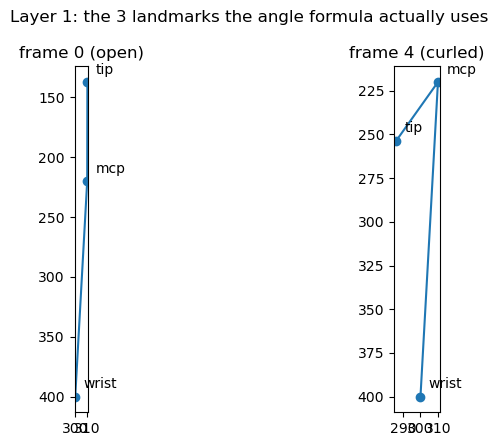

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, idx, label in zip(axes, [0, N_FRAMES - 1], ["frame 0 (open)", f"frame {N_FRAMES-1} (curled)"]):
    pts = np.array([WRIST, MCP, tips[idx]])
    ax.plot(pts[:, 0], pts[:, 1], "o-", color="tab:blue")
    for (x, y), name in zip(pts, ["wrist", "mcp", "tip"]):
        ax.annotate(name, (x, y), textcoords="offset points", xytext=(6, 6))
    ax.invert_yaxis()  # image coords: y grows downward
    ax.set_title(label)
    ax.set_aspect("equal")
plt.suptitle("Layer 1: the 3 landmarks the angle formula actually uses")
plt.tight_layout()
plt.show()


## Layer 2 — Landmarks → joint angle (the "protractor" step)

Copied verbatim from `get_angles()`, `vision/hand_tracker.py:106-108`:

```python
ba = a - b
bc = c - b
cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
angle = np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))
```

where `a=wrist`, `b=mcp`, `c=tip` for every finger except the thumb (which uses landmark 1
instead of the wrist — not relevant here since we're only tracing the index finger).

In [6]:
def joint_angle(wrist, mcp, tip):
    ba = wrist - mcp
    bc = tip - mcp
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return float(np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0))))

raw_angles = np.array([joint_angle(WRIST, MCP, tip) for tip in tips])

print("Raw angle per frame (degrees) - straight ~170, curled ~40:")
for i, a in enumerate(raw_angles):
    print(f"  frame {i}: {a:.1f} deg")


Raw angle per frame (degrees) - straight ~170, curled ~40:
  frame 0: 176.9 deg
  frame 1: 160.3 deg
  frame 2: 132.1 deg
  frame 3: 104.6 deg
  frame 4: 32.2 deg


## Layer 3 — EMA smoothing (on the angle, in degrees)

Copied verbatim from `hand_tracker.py:196-202`. First frame seeds the filter directly (no
history yet); every frame after blends `smoothing` (`a`, default `0.3`) of the new reading
with `1-a` of the previous smoothed value.

In [7]:
SMOOTHING = 0.3  # matches --smoothing default, hand_tracker.py:164

def ema_series(raw_values, a):
    smoothed = [raw_values[0]]  # first frame: smoothed = raw, hand_tracker.py:197
    for v in raw_values[1:]:
        smoothed.append(a * v + (1 - a) * smoothed[-1])
    return np.array(smoothed)

smoothed_angles = ema_series(raw_angles, SMOOTHING)

print(f"{'frame':>5} {'raw (deg)':>10} {'smoothed (deg)':>15}")
for i in range(N_FRAMES):
    print(f"{i:>5} {raw_angles[i]:>10.1f} {smoothed_angles[i]:>15.1f}")


frame  raw (deg)  smoothed (deg)
    0      176.9           176.9
    1      160.3           171.9
    2      132.1           160.0
    3      104.6           143.4
    4       32.2           110.0


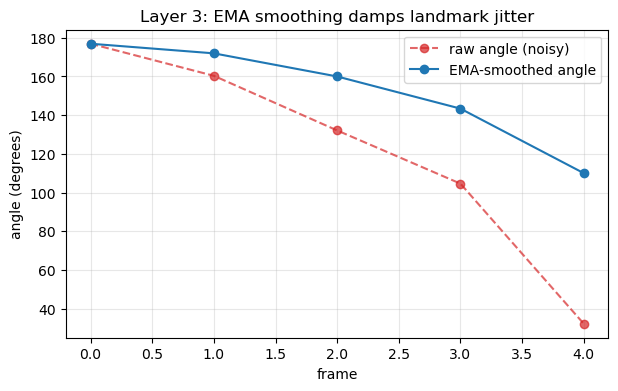

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(raw_angles, "o--", label="raw angle (noisy)", color="tab:red", alpha=0.7)
plt.plot(smoothed_angles, "o-", label="EMA-smoothed angle", color="tab:blue")
plt.xlabel("frame")
plt.ylabel("angle (degrees)")
plt.title("Layer 3: EMA smoothing damps landmark jitter")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Layer 4 — Smoothed angle → curl fraction (the "grading on a curve" step)

Copied verbatim from `curl_fraction()`, `hand_tracker.py:119-122`, using the real calibration
constants (`straight=170`, `curled=40`). The pipeline then inverts it (`1.0 - curl_fraction`,
`hand_tracker.py:210`) so the final convention is **0 = straight, 1 = fully curled** — this
inverted value is what actually gets sent to Gazebo.

In [9]:
def curl_fraction(angle, straight=170, curled=40):
    t = (angle - curled) / (straight - curled)
    return float(np.clip(t, 0.0, 1.0))

curl_open_pct   = np.array([curl_fraction(a) for a in smoothed_angles])   # 1.0 = straight
curl_closed_pct = 1.0 - curl_open_pct                                     # 1.0 = curled (Gazebo convention)

print(f"{'frame':>5} {'curl_fraction (straight=1)':>28} {'curl (curled=1, sent to sim)':>30}")
for i in range(N_FRAMES):
    print(f"{i:>5} {curl_open_pct[i]:>28.2f} {curl_closed_pct[i]:>30.2f}")


frame   curl_fraction (straight=1)   curl (curled=1, sent to sim)
    0                         1.00                           0.00
    1                         1.00                           0.00
    2                         0.92                           0.08
    3                         0.80                           0.20
    4                         0.54                           0.46


## Layer 5 — Fan-out: two actuator-specific commands

- **Servo path** (`angle_to_servo()`, `hand_tracker.py:125-128`): maps the smoothed angle to
  a 0-180 integer PWM-style command for the Arduino (`firmware/hand_controller/hand_controller.ino`).
- **Gazebo path** (`gz_hand_bridge.py:73-76`): scales the curl fraction (curled=1 convention)
  by `JOINT_MAX_RAD = 1.5708` to get a radian joint target, published to
  `/inmoov_left_hand/index1_joint/cmd_pos`.

In [10]:
def angle_to_servo(angle, servo_open=180, servo_closed=0):
    t = curl_fraction(angle)
    return int(servo_closed + t * (servo_open - servo_closed))

JOINT_MAX_RAD = 1.5708  # sim/bridge/gz_hand_bridge.py:45

servo_cmds = np.array([angle_to_servo(a) for a in smoothed_angles])
radian_targets = curl_closed_pct * JOINT_MAX_RAD

print(f"{'frame':>5} {'servo cmd (0-180)':>18} {'radian target (0-1.57)':>24}")
for i in range(N_FRAMES):
    print(f"{i:>5} {servo_cmds[i]:>18d} {radian_targets[i]:>24.3f}")


frame  servo cmd (0-180)   radian target (0-1.57)
    0                180                    0.000
    1                180                    0.000
    2                166                    0.121
    3                143                    0.322
    4                 96                    0.725


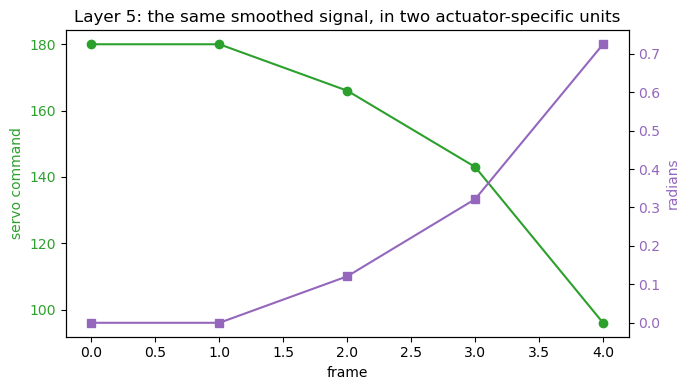

In [11]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(servo_cmds, "o-", color="tab:green", label="servo command (0-180)")
ax1.set_xlabel("frame")
ax1.set_ylabel("servo command", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")

ax2 = ax1.twinx()
ax2.plot(radian_targets, "s-", color="tab:purple", label="Gazebo radian target")
ax2.set_ylabel("radians", color="tab:purple")
ax2.tick_params(axis="y", labelcolor="tab:purple")

plt.title("Layer 5: the same smoothed signal, in two actuator-specific units")
fig.tight_layout()
plt.show()


## The full log (all 5 frames, every layer)

This is the single table you asked to keep as a running log — every intermediate value for
every frame, in one place.

In [12]:
log = pd.DataFrame({
    "frame": np.arange(N_FRAMES),
    "tip_x_px": tips[:, 0].round(1),
    "tip_y_px": tips[:, 1].round(1),
    "raw_angle_deg": raw_angles.round(1),
    "smoothed_angle_deg": smoothed_angles.round(1),
    "curl_open_pct": curl_open_pct.round(2),
    "curl_closed_pct": curl_closed_pct.round(2),
    "servo_cmd_0_180": servo_cmds,
    "radian_target": radian_targets.round(3),
})
log


,frame,tip_x_px,tip_y_px,raw_angle_deg,smoothed_angle_deg,curl_open_pct,curl_closed_pct,servo_cmd_0_180,radian_target
0,0,310.1,137.2,176.9,176.9,1.00,0.00,180,0.000
1,1,295.2,169.9,160.3,171.9,1.00,0.00,180,0.000
2,2,285.3,195.0,132.1,160.0,0.92,0.08,166,0.121
3,3,285.0,212.0,104.6,143.4,0.80,0.20,143,0.322
4,4,286.1,253.6,32.2,110.0,0.54,0.46,96,0.725


## Bonus experiment — the smoothing constant `a` is a real tradeoff, not a magic number

This regenerates a longer, noisier signal (20 frames, oscillating around a slowly moving true
value) and re-runs the exact same EMA formula at three different `a` values, so you can see
the snappy-vs-laggy tradeoff directly instead of taking it on faith.

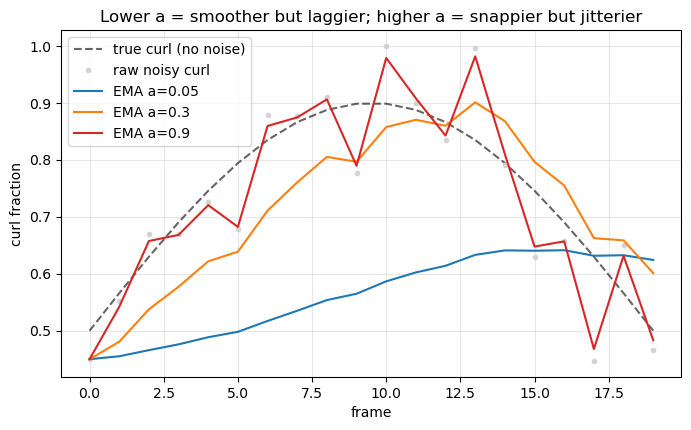

In [13]:
N_LONG = 20
true_curl = 0.5 + 0.4 * np.sin(np.linspace(0, np.pi, N_LONG))          # a slow real motion
noisy_curl = true_curl + np.random.normal(0, 0.08, size=N_LONG)         # + jitter, like real MediaPipe output
noisy_curl = np.clip(noisy_curl, 0.0, 1.0)

plt.figure(figsize=(8, 4.5))
plt.plot(true_curl, "k--", label="true curl (no noise)", alpha=0.6)
plt.plot(noisy_curl, ".", label="raw noisy curl", color="lightgray")
for a, color in zip([0.05, 0.3, 0.9], ["tab:blue", "tab:orange", "tab:red"]):
    plt.plot(ema_series(noisy_curl, a), "-", label=f"EMA a={a}", color=color)
plt.xlabel("frame")
plt.ylabel("curl fraction")
plt.title("Lower a = smoother but laggier; higher a = snappier but jitterier")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## What this notebook does *not* simulate

- **MediaPipe itself** (Layer 1's actual neural network) — the synthetic landmarks stand in
  for it. The noise model here (Gaussian jitter on the fingertip) is a simplification of
  whatever MediaPipe's real per-frame variance looks like.
- **The final physical/physics step** (servo PWM → tendon tension, or Gazebo's
  `JointPositionController` PID loop + `<mimic>` constraint propagation) — those live inside
  the Arduino's firmware loop and the physics engine's per-step solver respectively, not in
  Python you can run standalone here.

## Try this yourself
- Change `NOISE_SIGMA_PX` and watch how much it moves `raw_angle_deg` — that's the actual
  noise magnitude the EMA in Layer 3 has to fight.
- Change `SMOOTHING` (0.3 default) and re-run — compare against the bonus experiment above.
- Change `straight`/`curled` in `curl_fraction` to see how recalibrating for a different hand
  size or camera angle shifts every downstream number.
